In [1]:
import scanpy as sc
import scanpy.external as sce
import harmony
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plotnine import *
from scipy import stats

In [22]:
adata = sc.read_h5ad("sobj_kc_clean.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 30540 × 21819
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'X10x_cell_calling', 'G2M_score', 'S_score', 'barcode_rank', 'chemistry_10x', 'disease_status', 'empty_drops_FDR', 'ind_id', 'lesional', 'log10_n_genes', 'log10_n_umis', 'mito_cutoff_', 'mt_frac', 'n_counts', 'n_genes', 'n_umis', 'neg_log10_empty_drops_FDR', 'phase', 'predicted_cell_types', 'sample_name', 'scrublet', 'scrublet_score', 'sex', 'disease_lesional', 'batch', 'leiden', 'Cell.type', 'Cell.type.granular', 'ind_sample', 'channel', 'barcode', 'subject_id', 'global_disease_assessment', 'ad_family_history', 'sex_clinical', 'ethnicity_race', 'smoking', 'asthma', 'other_condition', 'systemic_corticosteroids', 'topical_corticosteroids', 'dupilumab', 'dupilumab_indication', 'dupilumab_other_indication', 'location', 'side', 'Disease.score..MADAD.Immune.', 'Disease.score..MADAD.Full.', 'Disease.score..MADAD.Union.', 'Cell.type.new.cornified', 'ind_disease_lesional', 'Cell.states.with.

In [23]:
kc_subsets = ["KC 5", "cKC"] # authors only run psuedotime on these kc subclasses
adata = adata[adata.obs["subset_group"].isin(kc_subsets)].copy() # subset adata only the defined kc_subsets

In [24]:
print(adata) # sanity check

AnnData object with n_obs × n_vars = 798 × 21819
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'X10x_cell_calling', 'G2M_score', 'S_score', 'barcode_rank', 'chemistry_10x', 'disease_status', 'empty_drops_FDR', 'ind_id', 'lesional', 'log10_n_genes', 'log10_n_umis', 'mito_cutoff_', 'mt_frac', 'n_counts', 'n_genes', 'n_umis', 'neg_log10_empty_drops_FDR', 'phase', 'predicted_cell_types', 'sample_name', 'scrublet', 'scrublet_score', 'sex', 'disease_lesional', 'batch', 'leiden', 'Cell.type', 'Cell.type.granular', 'ind_sample', 'channel', 'barcode', 'subject_id', 'global_disease_assessment', 'ad_family_history', 'sex_clinical', 'ethnicity_race', 'smoking', 'asthma', 'other_condition', 'systemic_corticosteroids', 'topical_corticosteroids', 'dupilumab', 'dupilumab_indication', 'dupilumab_other_indication', 'location', 'side', 'Disease.score..MADAD.Immune.', 'Disease.score..MADAD.Full.', 'Disease.score..MADAD.Union.', 'Cell.type.new.cornified', 'ind_disease_lesional', 'Cell.states.with.Pa

In [25]:
print(adata.shape)          # should only reflect KC5 + cKC cells
print(adata.var.columns)    # checking if highly_variable column already exists from previous run

(798, 21819)
Index([], dtype='object')


In [29]:
adata.layers["counts"]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 922313 stored elements and shape (798, 21819)>

In [30]:
sc.pp.highly_variable_genes(adata, n_top_genes=500, flavor="seurat")
adata = adata[:, adata.var.highly_variable].copy()

In [31]:
print(adata)

AnnData object with n_obs × n_vars = 798 × 500
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'X10x_cell_calling', 'G2M_score', 'S_score', 'barcode_rank', 'chemistry_10x', 'disease_status', 'empty_drops_FDR', 'ind_id', 'lesional', 'log10_n_genes', 'log10_n_umis', 'mito_cutoff_', 'mt_frac', 'n_counts', 'n_genes', 'n_umis', 'neg_log10_empty_drops_FDR', 'phase', 'predicted_cell_types', 'sample_name', 'scrublet', 'scrublet_score', 'sex', 'disease_lesional', 'batch', 'leiden', 'Cell.type', 'Cell.type.granular', 'ind_sample', 'channel', 'barcode', 'subject_id', 'global_disease_assessment', 'ad_family_history', 'sex_clinical', 'ethnicity_race', 'smoking', 'asthma', 'other_condition', 'systemic_corticosteroids', 'topical_corticosteroids', 'dupilumab', 'dupilumab_indication', 'dupilumab_other_indication', 'location', 'side', 'Disease.score..MADAD.Immune.', 'Disease.score..MADAD.Full.', 'Disease.score..MADAD.Union.', 'Cell.type.new.cornified', 'ind_disease_lesional', 'Cell.states.with.Path

In [37]:
print(adata.obs["ind_id"].value_counts())

ind_id
BCH05       227
BCH04       212
Healthy2    163
Healthy1    116
Healthy5     46
BCH01        34
Name: count, dtype: int64


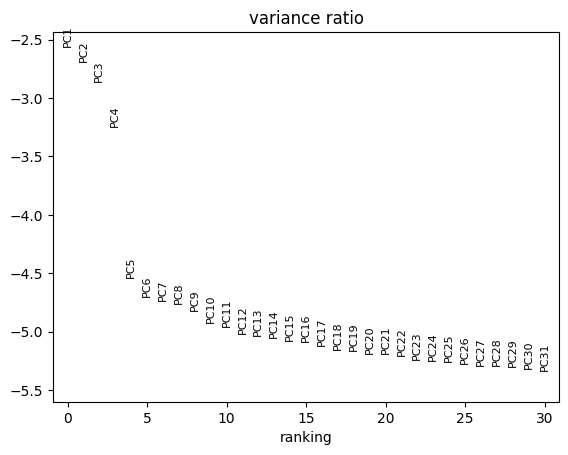

NaNs in X_pca: 0
Infs in X_pca: 0
X_pca shape: (798, 50)


In [100]:
# Scale data before PCA to prevent numerical instability
sc.pp.scale(adata, max_value=10)  # clip extreme values at 10

# --- PCA (authors used 50 PCs) --

sc.pp.pca(adata, n_comps=50, mask_var="highly_variable")
# elbow plot
sc.pl.pca_variance_ratio(adata, n_pcs=30, log=True) 
# reducing to only 15 PCs moving forwarddue to lower # of samples and cells-

# sanity checks
print("NaNs in X_pca:", np.isnan(adata.obsm["X_pca"]).sum())
print("Infs in X_pca:", np.isinf(adata.obsm["X_pca"]).sum())
print("X_pca shape:", adata.obsm["X_pca"].shape)  # should be (798, 20)

In [67]:
# more sanity checking 
print(np.isfinite(adata.obsm['X_pca']).all())

True


/Users/jeajung/miniforge3/envs/sc_env/lib/python3.10/site-packages/scanpy/preprocessing/_combat.py:344: RuntimeWarning: divide by zero encountered in divide


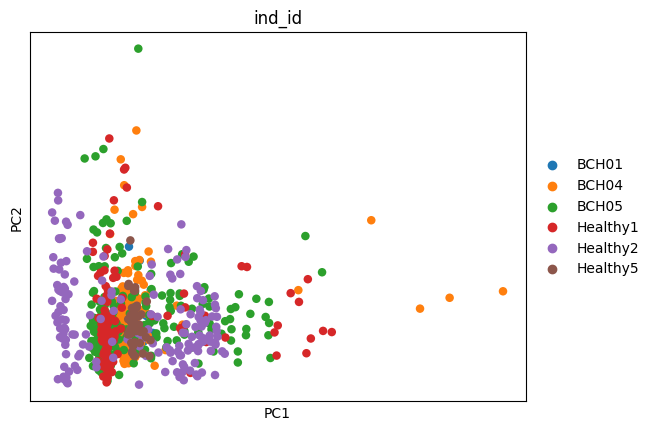

In [101]:
# Authors use pytorch harmony but that is overkill in this case (6 donors, 798 subset cells)

# 1. Ensure you have the 'ind_id' as a category
adata.obs['ind_id'] = adata.obs['ind_id'].astype('category')

# 2. Run ComBat on the .X matrix (normalized data)
# This will update adata.X with donor-corrected values
sc.pp.combat(adata, key='ind_id')

# 3. Re-run PCA on the corrected data
sc.pp.pca(adata, n_comps=15)
sc.pl.pca(adata, color='ind_id') # Verify the overlap

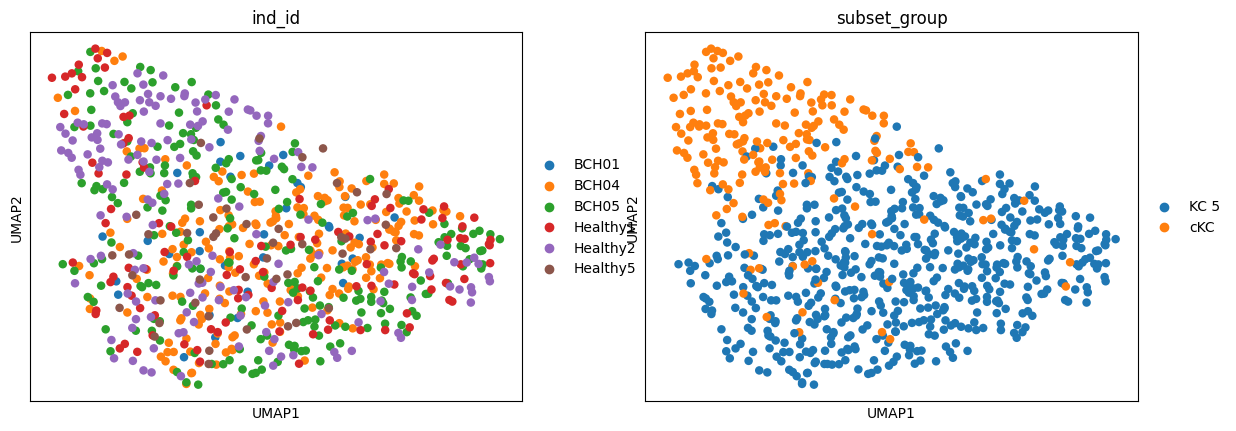

In [106]:
import scanpy.external as sce

# Running BBKNN instead of sc.pp.neighbors
sce.pp.bbknn(adata, batch_key='ind_id', n_pcs=15) # Creates a neighbor graph that is already batch-corrected

# umaps
sc.tl.umap(adata, random_state=42)
sc.pl.umap(adata, color=['ind_id', 'subset_group'])

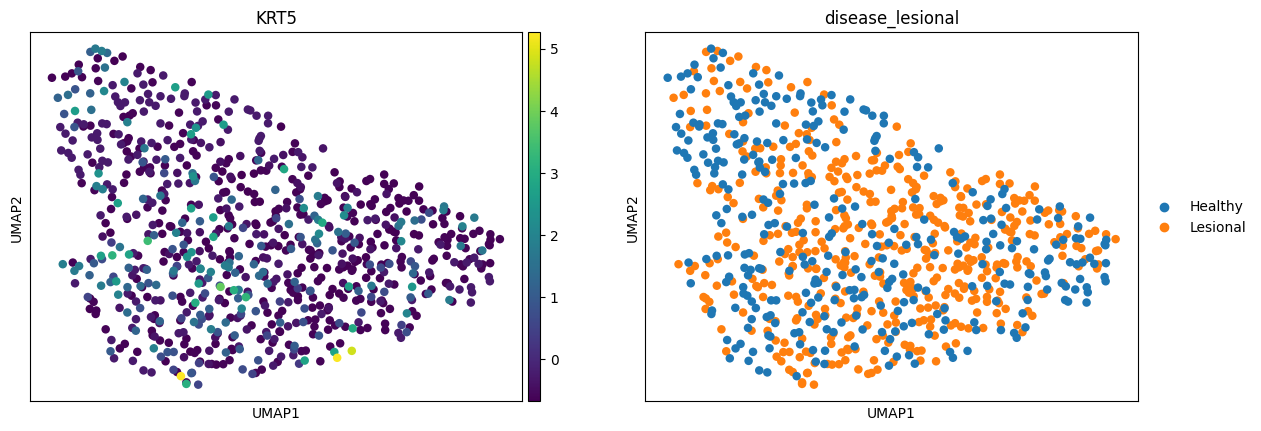

In [136]:
# KRT5 = basal marker
sc.pl.umap(adata, color=['KRT5', 'disease_lesional'], ncols=2)

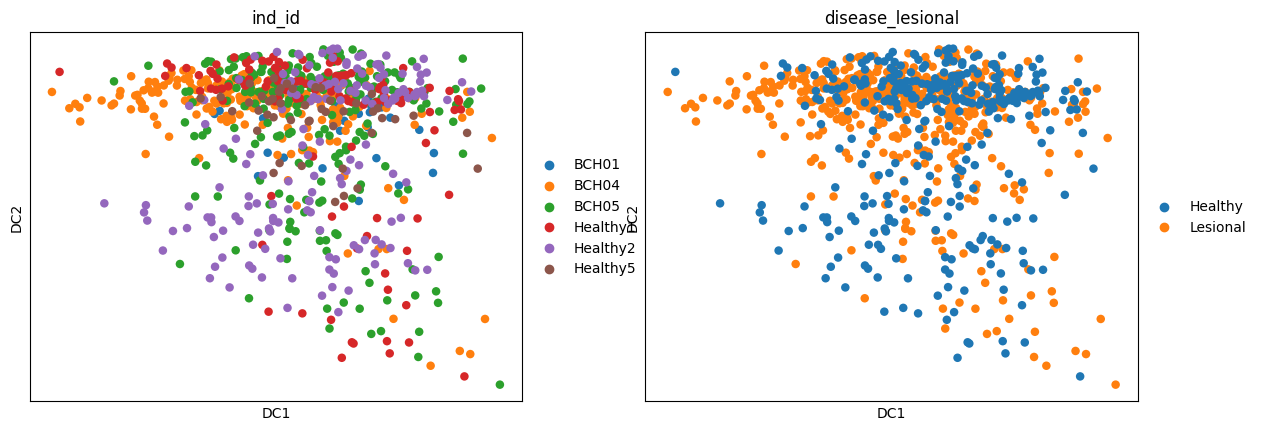

In [121]:
# Calculate Diffusion Maps
sc.tl.diffmap(adata, random_state=42)

# It's helpful to visualize the Diffusion Components (DCs) 
# to see if the trajectory 'stretches' out nicely
sc.pl.diffmap(adata, color=['ind_id', 'disease_lesional'])

In [138]:
basal_root_index = np.argmax(adata[:, 'KRT5'].X)
adata.uns['iroot'] = basal_root_index

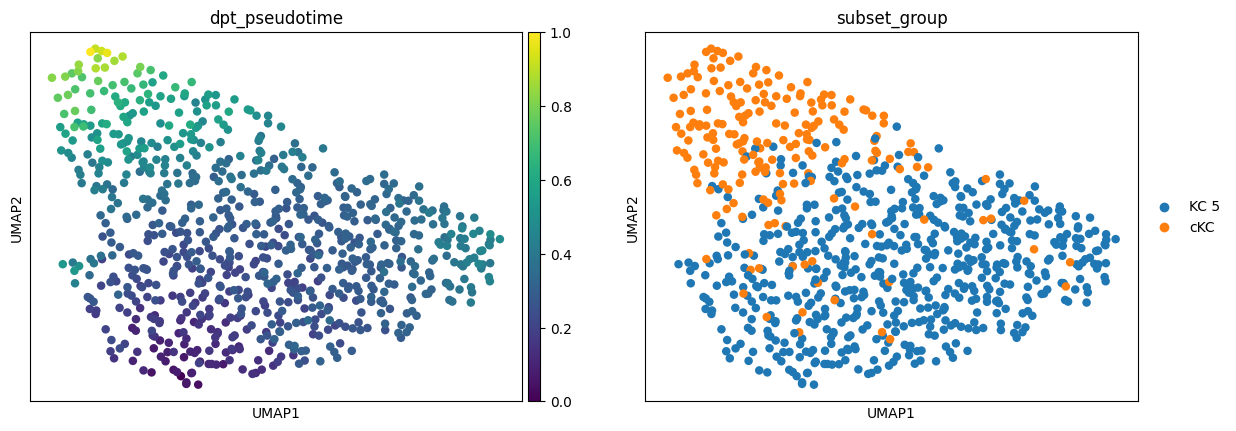

In [140]:
# Calculate Pseudotime
sc.tl.dpt(adata)

# The result is stored in adata.obs['dpt_pseudotime']
# Let's visualize it on your UMAP
sc.pl.umap(adata, color=['dpt_pseudotime', 'subset_group'], cmap='viridis')

In [141]:
from scipy.stats import mannwhitneyu
import pandas as pd

# Extract values
group_a = adata.obs[adata.obs['disease_lesional'] == 'Healthy']['dpt_pseudotime']
group_b = adata.obs[adata.obs['disease_lesional'] == 'Lesional']['dpt_pseudotime']

# Run Test
stat, p_val = mannwhitneyu(group_a, group_b)

print(f"DPT Pseudotime Comparison P-value: {p_val:.3e}")
print(f"Statistics: {stat:.3f}")

# 3. Quick Interpretation
if p_val < 0.05:
    print("Significant difference in pseudotime distribution between conditions.")
else:
    print("No significant difference in pseudotime distribution.")

DPT Pseudotime Comparison P-value: 2.031e-04
Statistics: 88749.000
Significant difference in pseudotime distribution between conditions.


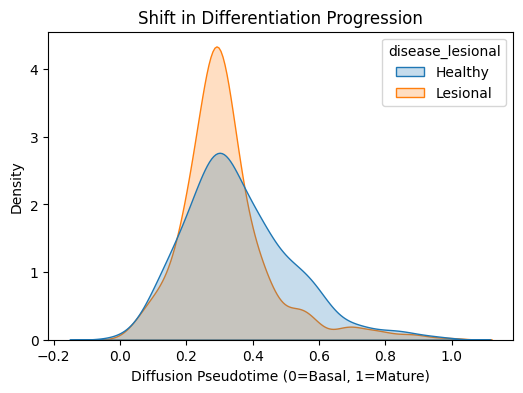

In [142]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.kdeplot(data=adata.obs, x='dpt_pseudotime', hue='disease_lesional', fill=True, common_norm=False)
plt.title("Shift in Differentiation Progression")
plt.xlabel("Diffusion Pseudotime (0=Basal, 1=Mature)")
plt.show()

Mann-Whitney U test revealed a significant shift in the differentiation landscape (U=88749, p=2.031×10−4), 
 with Lesional cells exhibiting a truncated differentiation profile compared to the more continuous maturation observed in Healthy controls.

In [159]:
print(adata.obs.groupby('disease_lesional')['dpt_pseudotime'].mean())

disease_lesional
Healthy     0.356031
Lesional    0.317233
Name: dpt_pseudotime, dtype: float32


/var/folders/r7/9r0jvgz52356p3x_x6nz14fw0000gn/T/ipykernel_33556/2339809647.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


# Checking points from authors: 
#### "This suggests a model where lesional AD is characterized by a shift from basal to cycling KCs, followed by decreased differentiation from KC5s to cKCs, leading to defective cornification"

### 1. "lesional KC5s had a significantly later DPT."

/var/folders/r7/9r0jvgz52356p3x_x6nz14fw0000gn/T/ipykernel_33556/546819823.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



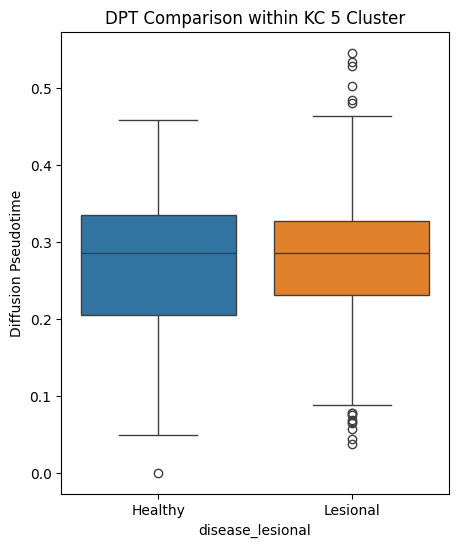

In [152]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for just the KC 5 (Basal/Progenitor) cluster
kc5_subset = adata[adata.obs['subset_group'] == 'KC 5'].copy()

plt.figure(figsize=(5, 6))
sns.boxplot(data=kc5_subset.obs, x='disease_lesional', y='dpt_pseudotime', 
            palette={'Healthy': '#1f77b4', 'Lesional': '#ff7f0e'})
plt.title('DPT Comparison within KC 5 Cluster')
plt.ylabel('Diffusion Pseudotime')
plt.show()

There is a slight observable increase of lesional KC5 cells in DPT than healthy KC5 cells, but not signficant. (Could be the case with more cells)

### 2. "decreased cell intrinsic expression of late cornified envelope genes in lesional AD KCs (e.g., LCE5A, LOR) and an increase in small proline rich proteins (SPRR)"

markers present in subset: ['KRT5', 'LCE5A']


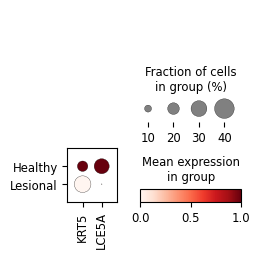

In [149]:
# List of genes from the paper
marker_genes = ['MKI67', 'KRT5', 'KRT10', 'LOR', 'LCE5A', 'SPRR1B']
# (Checking if these genes exist in my adata.var_names first)
available_markers = [g for g in marker_genes if g in adata.var_names]
print("markers present in subset:", available_markers)
# Plot expression levels by condition
sc.pl.dotplot(adata, available_markers, groupby='disease_lesional', standard_scale='var')

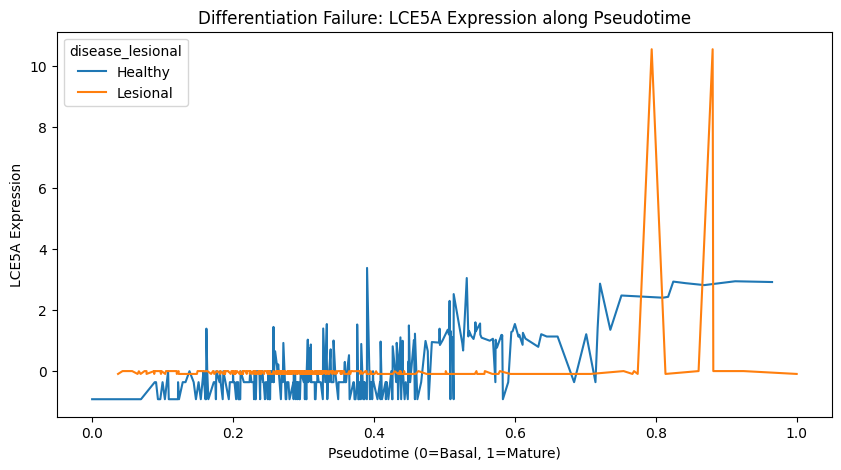

In [151]:
# dataframe for trend plotting
df = adata.obs[['dpt_pseudotime', 'disease_lesional']].copy()
df['LCE5A_expression'] = adata[:, 'LCE5A'].X.toarray().flatten() if 'LCE5A' in adata.var_names else 0

plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='dpt_pseudotime', y='LCE5A_expression', hue='disease_lesional')
plt.title('Differentiation Failure: LCE5A Expression along Pseudotime')
plt.xlabel('Pseudotime (0=Basal, 1=Mature)')
plt.ylabel('LCE5A Expression')
plt.show()

This claim is observable true, despite the 2 outlier peaks (could be related to defective cornification?), the trend is consistently lower in lesional KC5 cells.

In [163]:
# TODO; run trajectory inclusive of KC1, KC2, KC3, KC5 cells
# TODO: output plots, create script version
adata.write('kc5_cKC_integrated_trajectory.h5ad')